# Autoencoder (AE) - PyTorch


Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.7MB/s]


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
Epoch [1/20], Loss: 0.2929
Epoch [2/20], Loss: 0.2034
Epoch [3/20], Loss: 0.1641
Epoch [4/20], Loss: 0.1492
Epoch [5/20], Loss: 0.1386
Epoch [6/20], Loss: 0.1329
Epoch [7/20], Loss: 0.1286
Epoch [8/20], Loss: 0.1248
Epoch [9/20], Loss: 0.1211
Epoch [10/20], Loss: 0.1179
Epoch [11/20], Loss: 0.1155
Epoch [12/20], Loss: 0.1137
Epoch [13/20], Loss: 0.1122
Epoch [14/20], Loss: 0.1111
Epoch [15/20], Loss: 0.1100
Epoch [16/20], Loss: 0.1089
Epoch [17/20], Loss: 0.

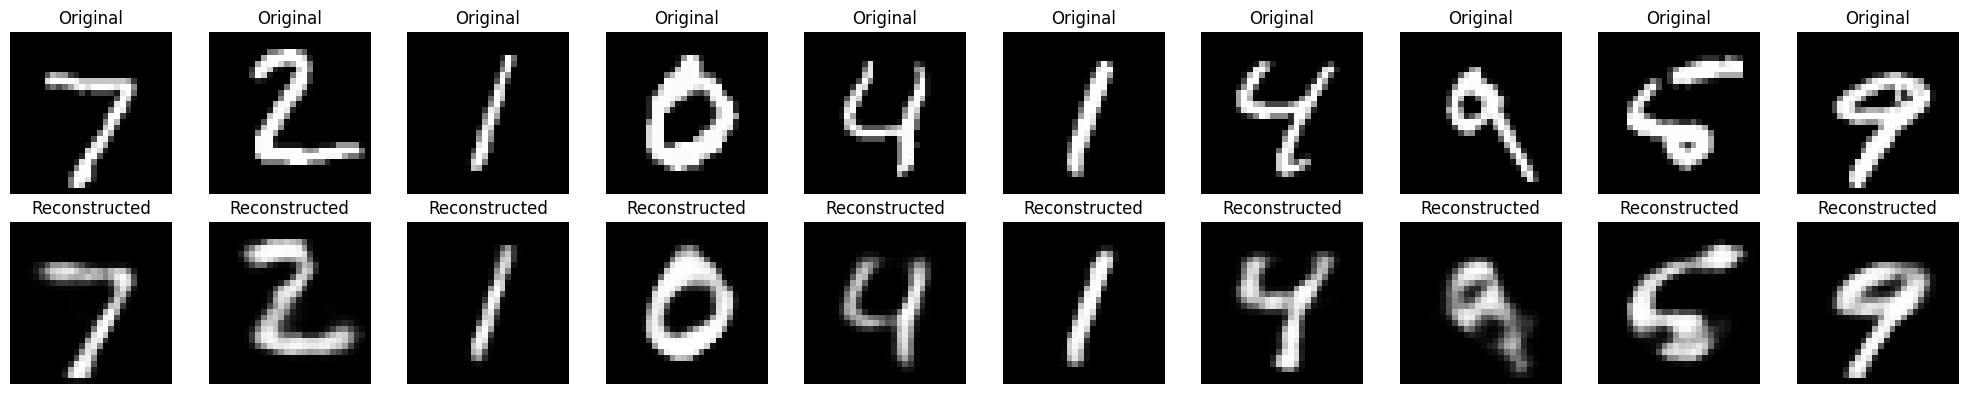

Encoded Vector Shape: torch.Size([1, 32])
tensor([[10.5997,  7.7941, 17.2755, 10.4122,  9.7810, 11.0311,  5.7423,  0.0000,
          0.0000, 20.3442,  4.7464, 12.1399,  0.0000,  0.0000,  6.1190,  5.9625,
          8.6274, 14.7672,  0.0000,  7.5914,  0.0000,  5.7211, 12.8017,  8.7112,
          0.0000,  0.0000,  0.0000, 16.0399, 15.7301,  0.0000,  0.0000,  4.3017]],
       device='cuda:0', grad_fn=<ReluBackward0>)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================
# 1. Device Configuration
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 2. Load MNIST Dataset
# =========================
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data',
                               train=True,
                               download=True,
                               transform=transform)

test_dataset = datasets.MNIST(root='./data',
                              train=False,
                              download=True,
                              transform=transform)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=256,
                          shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=10,
                         shuffle=False)

# =========================
# 3. Define Autoencoder
# =========================
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU())

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid())

    def forward(self, x):
        # Flatten image
        x = x.view(-1, 28 * 28)
        # Encode
        encoded = self.encoder(x)
        # Decode
        decoded = self.decoder(encoded)
        return decoded

# Initialize model
model = Autoencoder().to(device)
print(model)

# =========================
# 4. Loss and Optimizer
# =========================
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# =========================
# 5. Train Model
# =========================
num_epochs = 20

for epoch in range(num_epochs):
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        # Flatten images for target
        images_flat = images.view(-1, 28 * 28)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, images_flat)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

print("Training Complete!")

# =========================
# 6. Test Reconstruction
# =========================
model.eval()

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        reconstructed = model(images)

        # Reshape for visualization
        reconstructed = reconstructed.view(-1, 1, 28, 28)

        # Move to CPU
        images = images.cpu()
        reconstructed = reconstructed.cpu()
        break

# =========================
# 7. Visualize Results
# =========================
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original Images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed Images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# 8. Extract Encoded Features
# =========================
sample = images[0].view(-1, 28 * 28).to(device)
encoded_vector = model.encoder(sample)

print("Encoded Vector Shape:", encoded_vector.shape)
print(encoded_vector)